In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


Image shape: (480, 640, 3)


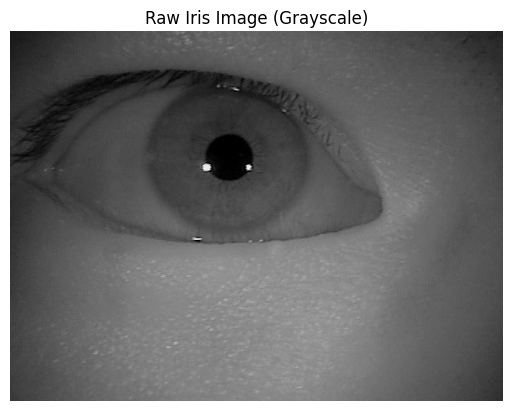

In [24]:
image_path = r"../data/CASIA/CASIA-Iris-Thousand/CASIA-Iris-Thousand/005/L/S5005L00.jpg"
image = cv2.imread(image_path)

if image is None:
    raise ValueError("Image not found. Check dataset path.")

print("Image shape:", image.shape)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Raw Iris Image (Grayscale)")
plt.axis("off")
plt.show()

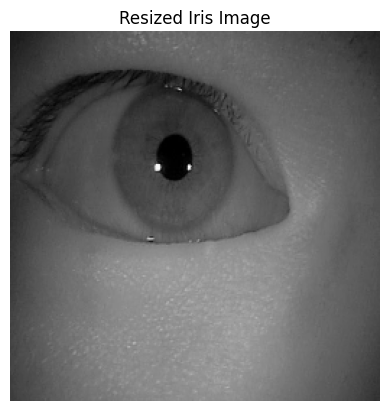

In [25]:
resized = cv2.resize(gray, (256, 256))

plt.imshow(resized, cmap='gray')
plt.title("Resized Iris Image")
plt.axis("off")
plt.show()

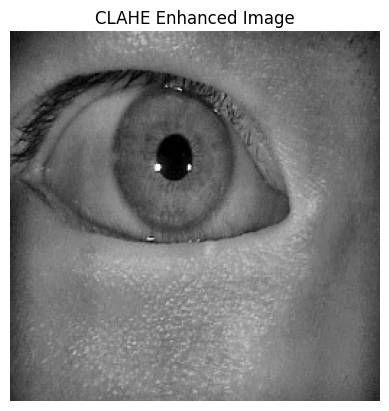

In [27]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(resized)

plt.imshow(enhanced, cmap='gray')
plt.title("CLAHE Enhanced Image")
plt.axis("off")
plt.show()

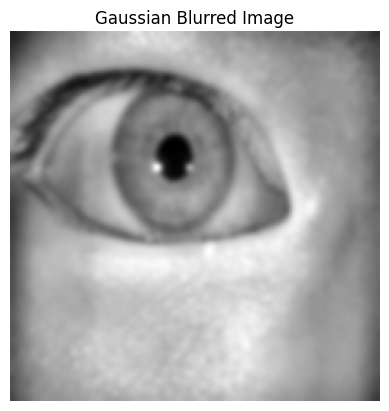

In [28]:
blur = cv2.GaussianBlur(enhanced, (9,9), 2)

plt.imshow(blur, cmap='gray')
plt.title("Gaussian Blurred Image")
plt.axis("off")
plt.show()

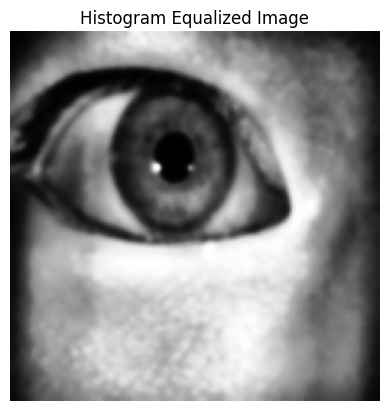

In [29]:
equalized = cv2.equalizeHist(blur)

plt.imshow(equalized, cmap='gray')
plt.title("Histogram Equalized Image")
plt.axis("off")
plt.show()

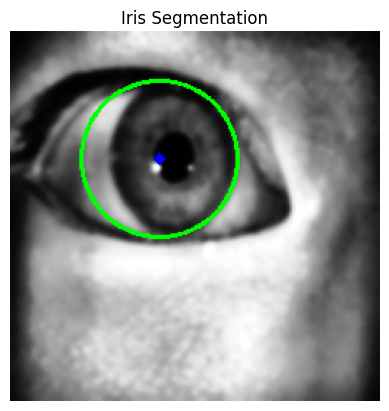

In [34]:
circles = cv2.HoughCircles(
    equalized,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=80,
    param1=100,
    param2=30,
    minRadius=40,
    maxRadius=100
)

output = cv2.cvtColor(equalized, cv2.COLOR_GRAY2BGR)

if circles is None:
    raise ValueError("No iris detected. Adjust Hough parameters.")

circles = np.round(circles[0]).astype("int")

x, y, r = circles[0]

cv2.circle(output, (x, y), r, (0, 255, 0), 2)
cv2.circle(output, (x, y), 2, (255, 0, 0), 3)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Iris Segmentation")
plt.axis("off")
plt.show()

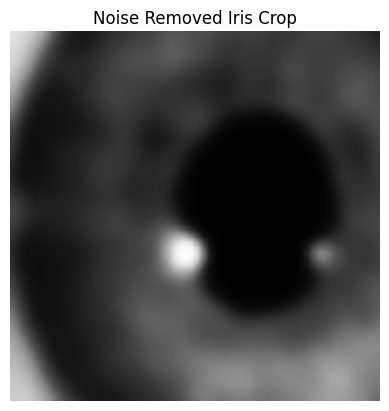

In [35]:
# reduce radius to avoid eyelids/noise
r = int(r * 0.60)

x1 = max(x - r, 0)
y1 = max(y - r, 0)
x2 = min(x + r, equalized.shape[1])
y2 = min(y + r, equalized.shape[0])

iris_crop = equalized[y1:y2, x1:x2]

iris_crop = cv2.resize(iris_crop, (224, 224))

plt.imshow(iris_crop, cmap='gray')
plt.title("Noise Removed Iris Crop")
plt.axis("off")
plt.show()

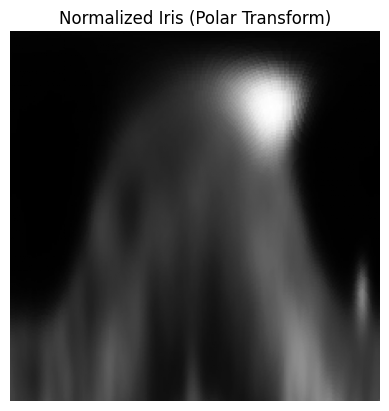

In [39]:
polar_iris = cv2.warpPolar(
    iris_crop,
    (224, 224),
    (112, 112),
    112,
    cv2.WARP_POLAR_LINEAR
)

polar_iris = cv2.rotate(polar_iris, cv2.ROTATE_90_CLOCKWISE)

plt.imshow(polar_iris, cmap='gray')
plt.title("Normalized Iris (Polar Transform)")
plt.axis("off")
plt.show()

In [40]:
cv2.imwrite("../results/week2_results/Raw Iris Image (Grayscale).jpg", gray)

print("Image saved successfully")

Image saved successfully


In [41]:
cv2.imwrite("../results/week2_results/Resized Image.jpg", resized)

print("Image saved successfully")

Image saved successfully


In [42]:
cv2.imwrite("../results/week2_results/Gaussian Blurred Image.jpg", blur)

print("Image saved successfully")

Image saved successfully


In [43]:
cv2.imwrite("../results/week2_results/CLAHE Enhanced Iris.jpg", enhanced)

print("Image saved successfully")

Image saved successfully


In [44]:
cv2.imwrite("../results/week2_results/Histogram Equalization.jpg",equalized)

print("Image saved successfully")

Image saved successfully


In [45]:
cv2.imwrite("../results/week2_results/segmented_iris.jpg", output)

print("Image saved successfully")

Image saved successfully


In [46]:
cv2.imwrite("../results/week2_results/Noise Removed Iris Crop.jpg", iris_crop)

print("Image saved successfully")

Image saved successfully


In [47]:
cv2.imwrite("../results/week2_results/Normalized Polar Iris Image.jpg", polar_iris)

print("Image saved successfully")

Image saved successfully
